# ENGR-E 221 Homework 4: Linear Regression Models

In [19]:
#import the required libraries
import os
import pandas as pd
import numpy as np

#import the csv file, using the ; separator
my_dataset = pd.read_csv("/Users/zeynepamac/Desktop/E221/hw4/Electricity_Consumption.csv", sep=",")
my_dataset.shape

my_dataset.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620


# **Data Preprocessing (10 points)**

In [71]:
#counts the total number of duplicate rows in the data frame
print("Duplicated rows:", my_dataset.duplicated().sum())


#will loop for each column in the column list and if there is a missing value, it will print it
for column in my_dataset.columns:
    if my_dataset[column].isnull().sum() != 0:
        print(f"{column} -> Missing Values : {my_dataset[column].isnull().sum()}, dtypes : {my_dataset[column].dtypes}")



Duplicated rows: 0


In [ ]:
# check for categorical columns
categorical_columns = my_dataset.select_dtypes(include="object").columns

print("Categorical columns:", categorical_columns.tolist())

Categorical columns: ['DateTime']


In [15]:
#convert date label to actual date
my_dataset["DateTime"] = pd.to_datetime(my_dataset["DateTime"])
print(my_dataset["DateTime"].dtype)

# convert useful numerical features from datetime
my_dataset["Hour"] = my_dataset["DateTime"].dt.hour
my_dataset["Month"] = my_dataset["DateTime"].dt.month
my_dataset["DayOfWeek"] = my_dataset["DateTime"].dt.dayofweek

my_dataset.head()

datetime64[ns]


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption,Hour,Month,DayOfWeek
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,0,1,6
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,0,1,6
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,0,1,6
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,0,1,6
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,0,1,6


# **Multicollinearity Analysis (8 points)**

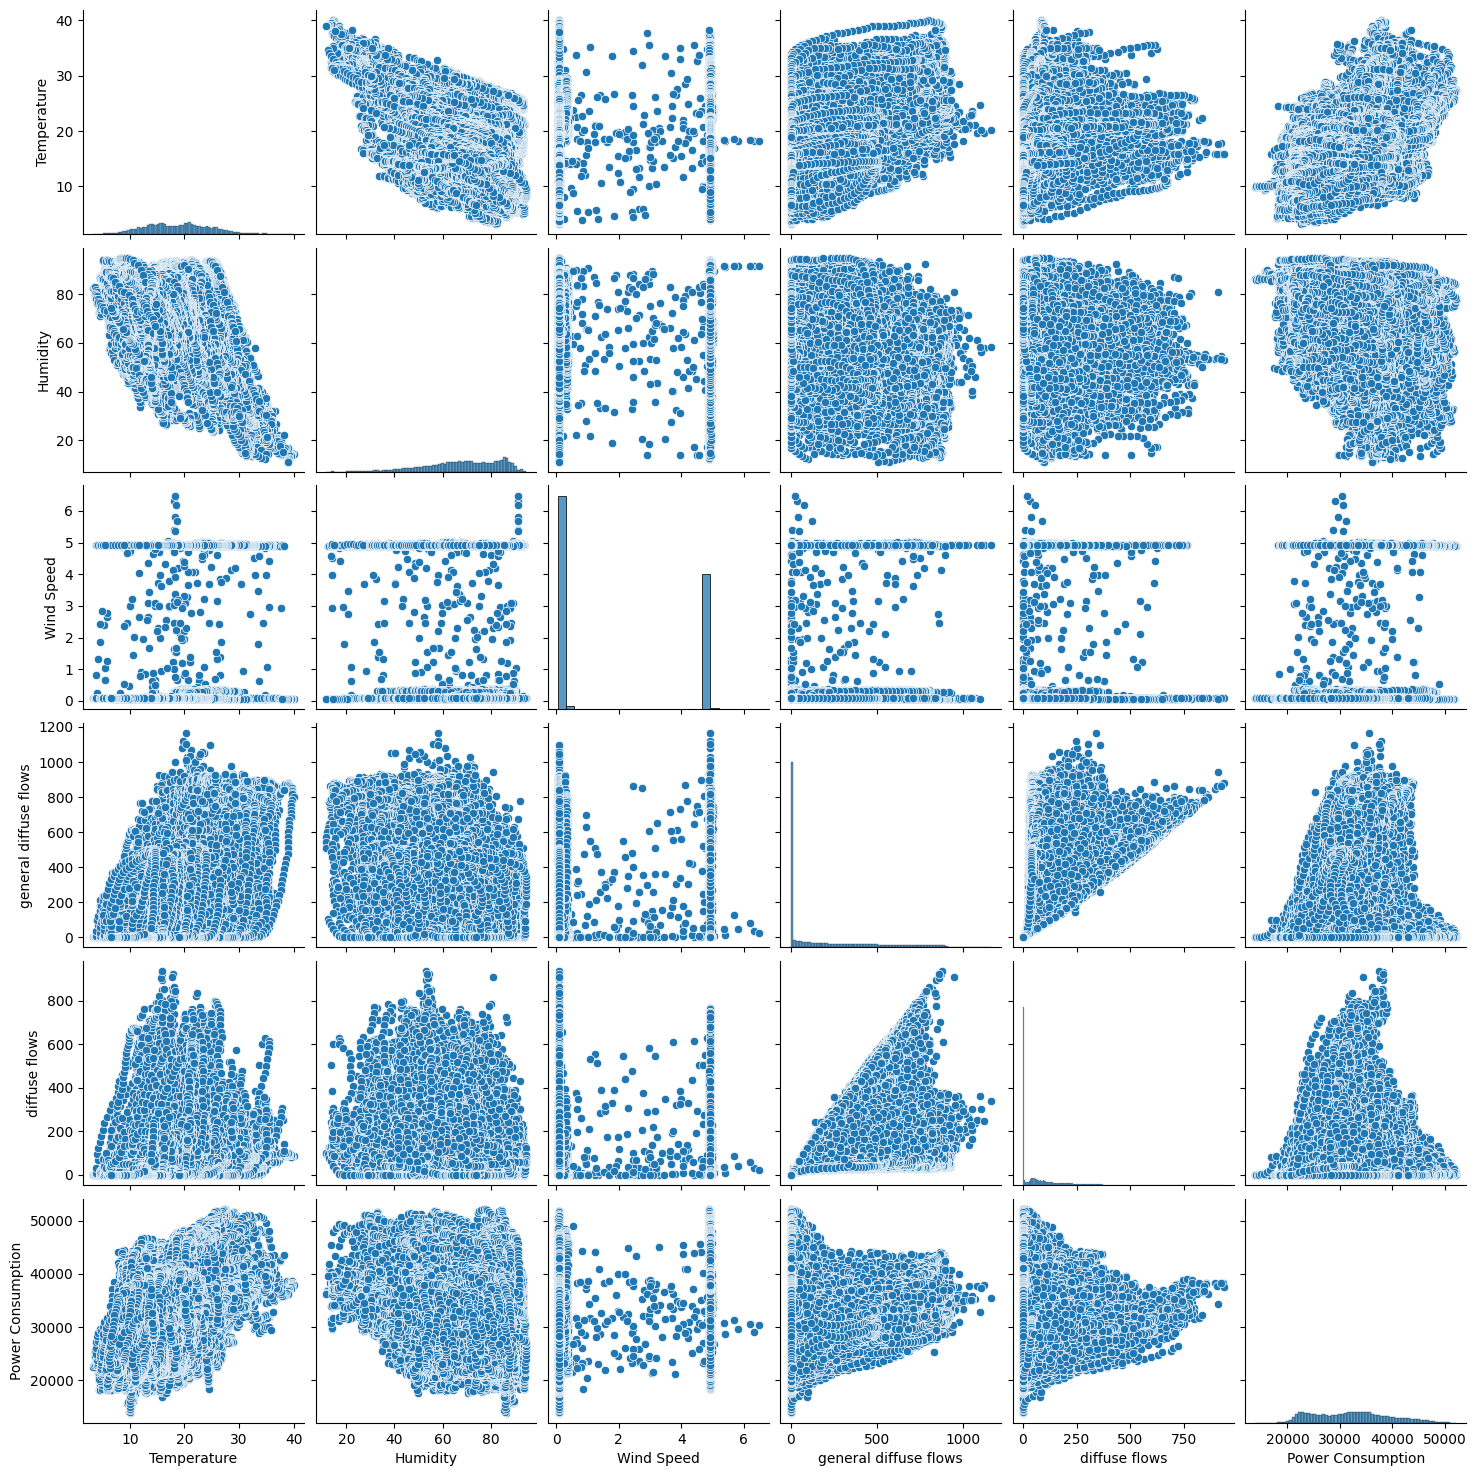

In [72]:
import seaborn as sb
sb.pairplot(my_dataset) # plot histogram for each column

# **Simple Linear Regression (8 points)**

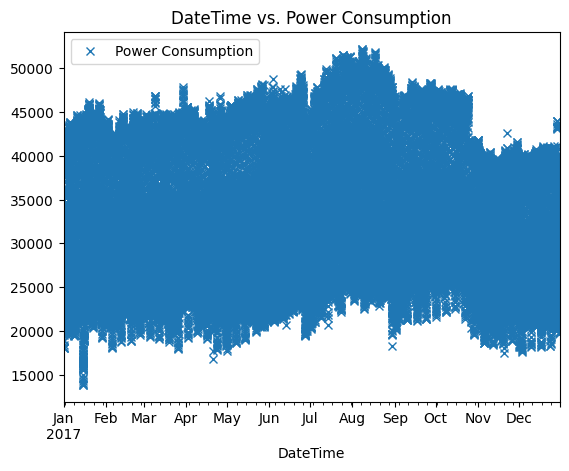

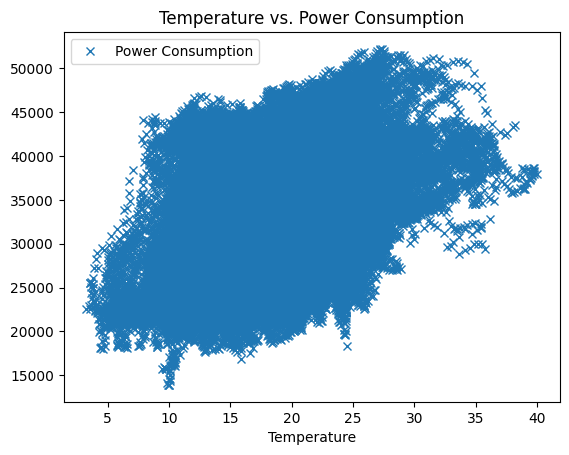

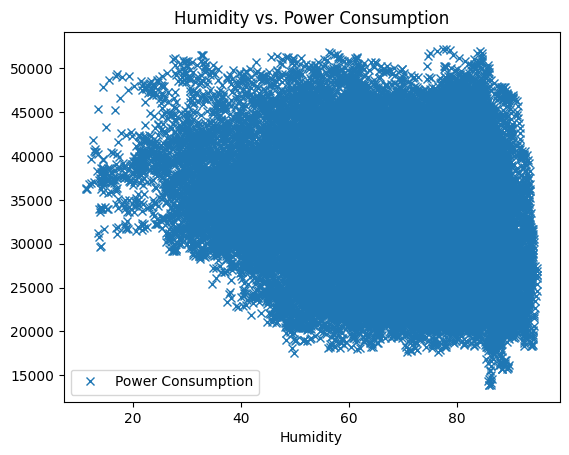

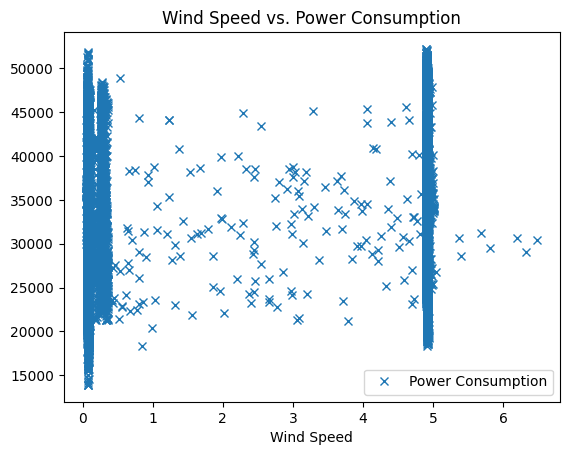

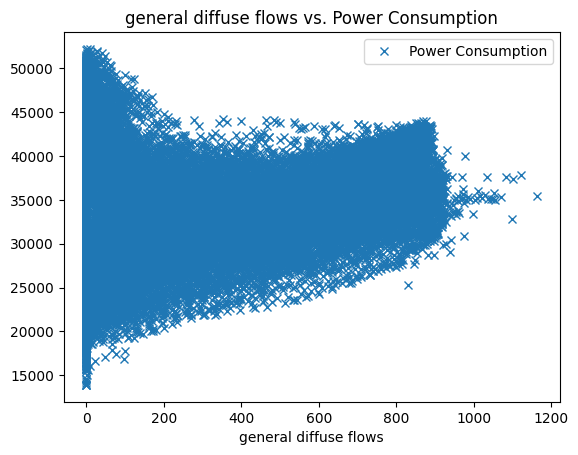

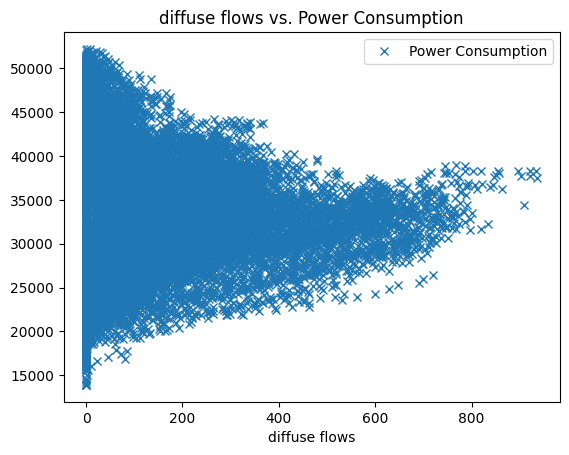

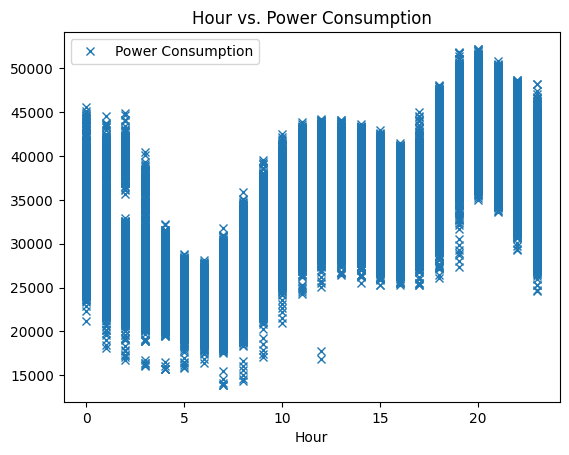

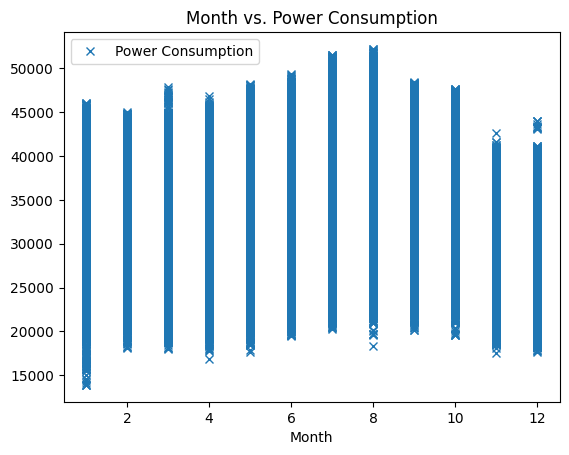

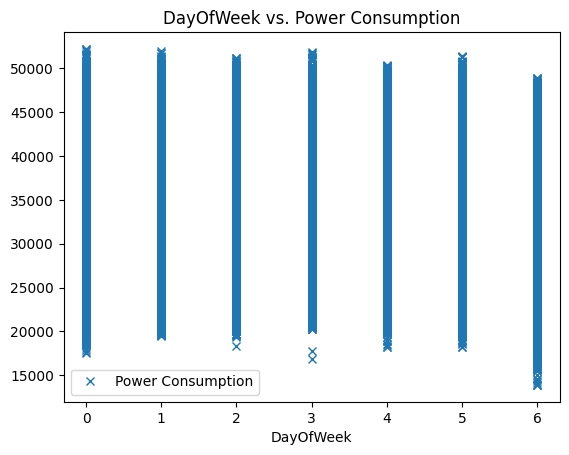

In [ ]:
# import necessary libraries

import matplotlib.pyplot as plt

# Part A

feature_columns = my_dataset.columns.drop("Power Consumption") #drop the target column

for feature in feature_columns: #loop through each column and then create columns against "Power Consumption"
    my_dataset.plot(x=feature,y="Power Consumption", style="x",title=f"{feature} vs. Power Consumption")

In [ ]:
# temperature and power consumption
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression



split = 0.2 #set a value to split

x = my_dataset[["Temperature"]]

y = my_dataset["Power Consumption"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=split, random_state=0)

# build and train the linear regression model
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[537.94]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.222e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [54]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (41932, 1)
y_train shape: (41932,)
x_test shape: (10484, 1)
y_test shape: (10484,)


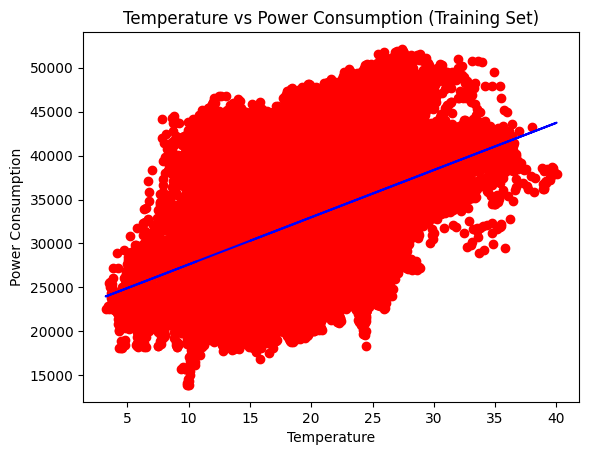

In [55]:
#get predicted probabilities
# Assuming y_test are actual values and y_pred are your predictions

import matplotlib.pyplot as plt


# Predict power consumption
y_pred = lin_reg.predict(x_test)

# Plot actual training data
plt.scatter(x_train, y_train, color="red")

# Plot regression line
plt.plot(x_train, lin_reg.predict(x_train), color="blue")

plt.title("Temperature vs Power Consumption (Training Set)")
plt.xlabel("Temperature")
plt.ylabel("Power Consumption")

plt.show()


# **Polynomial Regression (8 points)**

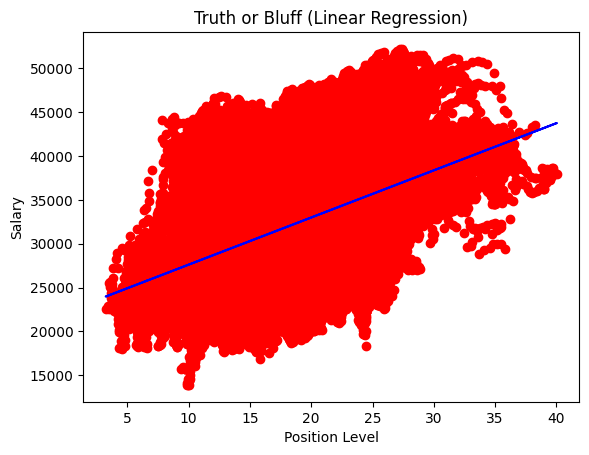

In [ ]:

# Assuming y_test are actual values and y_pred are your predictions
import matplotlib.pyplot as plt

# Predict power consumption
y_pred = lin_reg.predict(x_test)

# Plot actual training data
plt.scatter(x, y, color = 'red')
plt.plot(x, lin_reg.predict(x), color = 'blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

# **Multiple Linear Regression (8 points)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Multiple predictor variables
x = my_dataset.drop(columns=["DateTime", "Power Consumption"])

# Target
y = my_dataset["Power Consumption"]

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

# Create and train model
regressor = LinearRegression()
regressor.fit(x_train, y_train)

# Make predictions
y_pred = regressor.predict(x_test)

# **Model Comparison in Your Own Words (8 points)**

Resources I've used:
- https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
- https://sawtoothsoftware.com/resources/blog/posts/addressing-multicollinearity
- https://scikit-learn.org/stable/modules/model_evaluation.html
- https://stackoverflow.com/questions/45627784/unable-to-obtain-accuracy-score-for-my-linear-regression
- https://www.geeksforgeeks.org/machine-learning/multicollinearity-in-regression-analysis/
